In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import scienceplots

from qr.utils import *

sns.set_style("whitegrid")

In [2]:
ticker = "PFE"
alpha_pnl_no_impact = pl.read_csv(
    Path.home()
    / f"dev_cpp/qr/data/results/{ticker}/samples/76618e56e87aa2a5_alpha_pnl.csv"
)
alpha_pnl_impact = pl.read_csv(
    Path.home()
    / f"dev_cpp/qr/data/results/{ticker}/samples/338434a637f39f7d_alpha_pnl.csv"
)

In [3]:
df_no_impact = pl.read_parquet(
    Path.home() / f"dev_cpp/qr/data/results/{ticker}/samples/76618e56e87aa2a5.parquet"
)
df_impact = pl.read_parquet(
    Path.home() / f"dev_cpp/qr/data/results/{ticker}/samples/338434a637f39f7d.parquet"
)

In [4]:
def alpha_predictiveness(df, horizons_min, n_bootstrap=100, block_size=10, seed=42):
    bars = (
        df.with_columns(minute=pl.col("ts_event") // int(60e9))
        .group_by("minute")
        .agg(pl.col("mid").last(), pl.col("alpha").mean())
        .sort("minute")
    )
    mid = bars["mid"].to_numpy()
    alpha = bars["alpha"].to_numpy()
    rng = np.random.default_rng(seed)

    results = []
    for h in horizons_min:
        delta_p = mid[h:] - mid[:-h]
        product = alpha[:-h] * delta_p
        mean_val = product.mean()

        n_blocks = product.size // block_size
        product_blocks = product[: n_blocks * block_size].reshape(-1, block_size)

        indices = rng.integers(
            0, product_blocks.shape[0], size=(n_bootstrap, product_blocks.shape[0])
        )
        boot_means = product_blocks[indices].mean(axis=(1, 2))

        ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
        results.append(
            {"horizon_min": h, "mean": mean_val, "ci_lo": ci_lo, "ci_hi": ci_hi}
        )

    return pl.DataFrame(results)

In [5]:
horizons = list(range(1, 31))
res_no = alpha_predictiveness(df_no_impact, horizons)
res_im = alpha_predictiveness(df_impact, horizons)

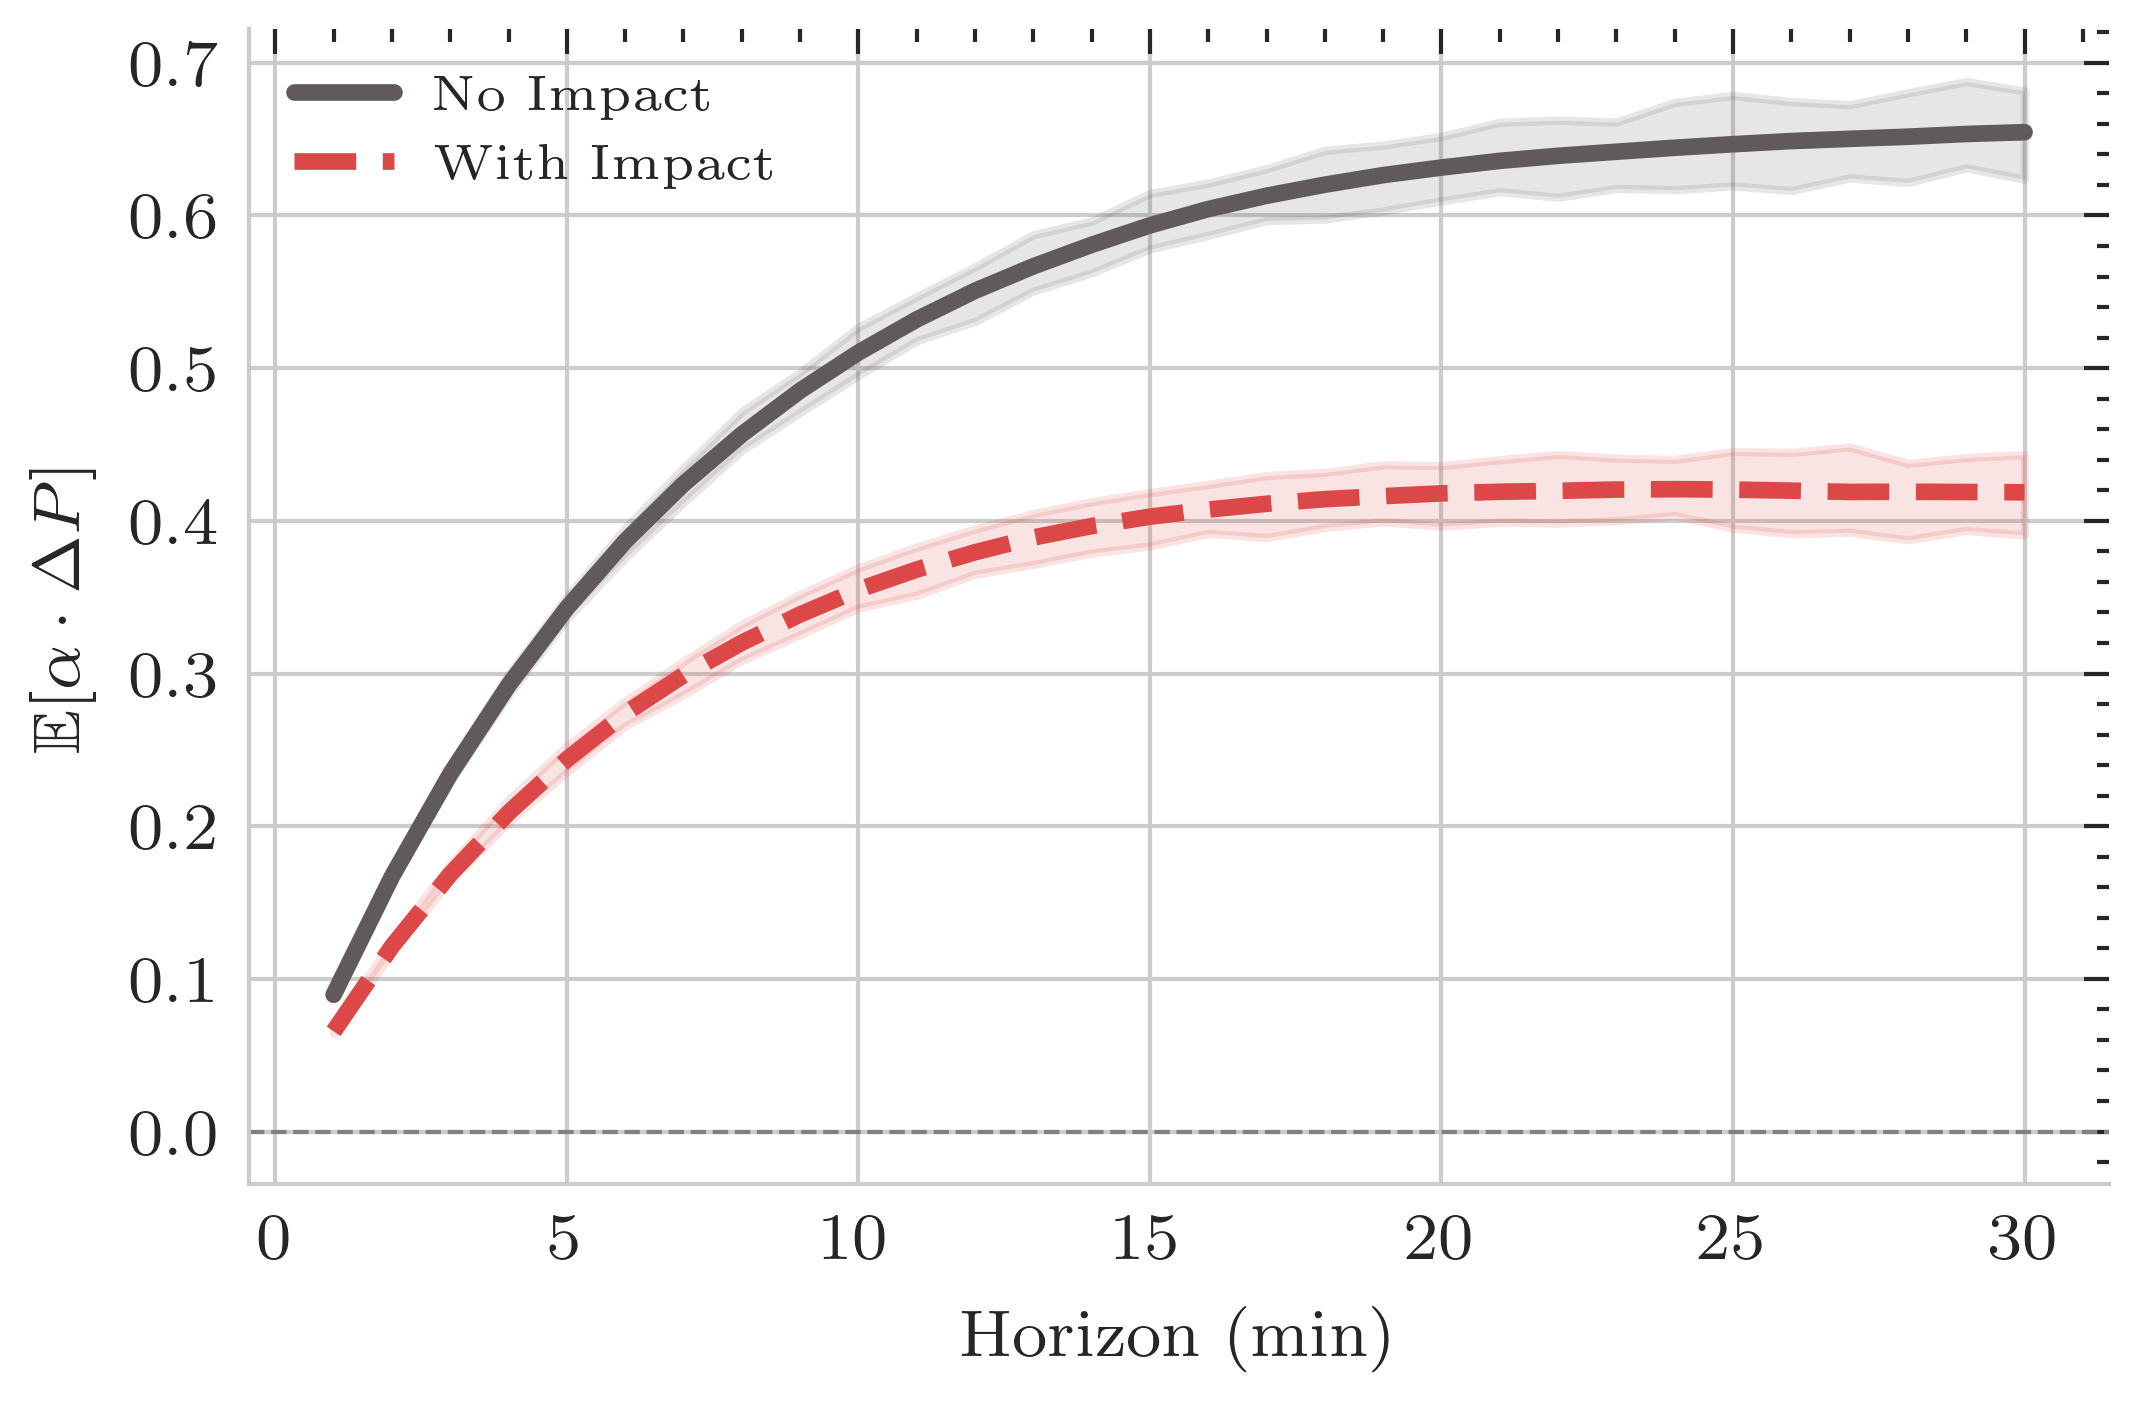

In [11]:
with ieee():
    fig, ax = plt.subplots(figsize=(4, 2.5))

    for res, label, color in [
        (res_no, "No Impact", "#615A5A"),
        (res_im, "With Impact", "#DC4848"),
    ]:
        ax.plot(
            res["horizon_min"],
            res["mean"],
            lw=2,
            color=color,
            label=label,
        )
        ax.fill_between(
            res["horizon_min"], res["ci_lo"], res["ci_hi"], alpha=0.15, color=color
        )

    ax.axhline(0, color="grey", lw=0.5, ls="--")
    ax.set_xlabel("Horizon (min)")
    ax.set_ylabel(r"$\mathbb{E}[\alpha \cdot \Delta P]$")
    ax.legend(fontsize=6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # fig.savefig("../../paper/alpha_deltaP_PFE.pdf", bbox_inches="tight")
    plt.show()

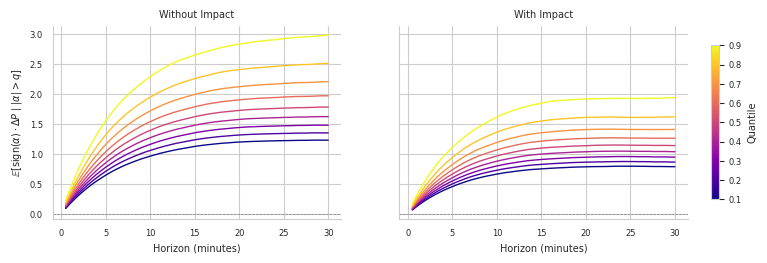

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 2.5), sharey=True)

thresholds = sorted(alpha_pnl_no_impact["quantile"].unique().to_list())
norm = mcolors.Normalize(vmin=min(thresholds), vmax=max(thresholds))
cmap = cm.plasma

for thr in thresholds:
    color = cmap(norm(thr))
    sub_no = alpha_pnl_no_impact.filter(pl.col("quantile").eq(thr))
    sub_im = alpha_pnl_impact.filter(pl.col("quantile").eq(thr))

    ax1.plot(sub_no["lag_sec"] / 60, sub_no["alpha_tickreturn_cov"], color=color, lw=1)
    ax2.plot(sub_im["lag_sec"] / 60, sub_im["alpha_tickreturn_cov"], color=color, lw=1)

for ax, title in [(ax1, "Without Impact"), (ax2, "With Impact")]:
    ax.axhline(0, color="grey", lw=0.5, ls="--")
    ax.set_title(title, fontsize=7)
    ax.set_xlabel("Horizon (minutes)", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

ax1.set_ylabel(
    r"$\mathbb{E}[\mathrm{sign}(\alpha) \cdot \Delta P \mid |\alpha| > q]$", fontsize=7
)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=[ax1, ax2], shrink=0.8, pad=0.03)
cbar.set_label("Quantile", fontsize=7)
cbar.ax.tick_params(labelsize=6)

# fig.savefig("../../paper/alpha_deltaP_PFE.pdf", bbox_inches="tight")
plt.show()

In [4]:
ticker = "PFE"
pnl_no_impact = pl.read_parquet(
    Path.home() / f"dev_cpp/qr/data/results/{ticker}/strategy/b87b96ef18b4b493.parquet"
)
pnl_impact = pl.read_parquet(
    Path.home() / f"dev_cpp/qr/data/results/{ticker}/strategy/80cdf761e7d02bb3.parquet"
)

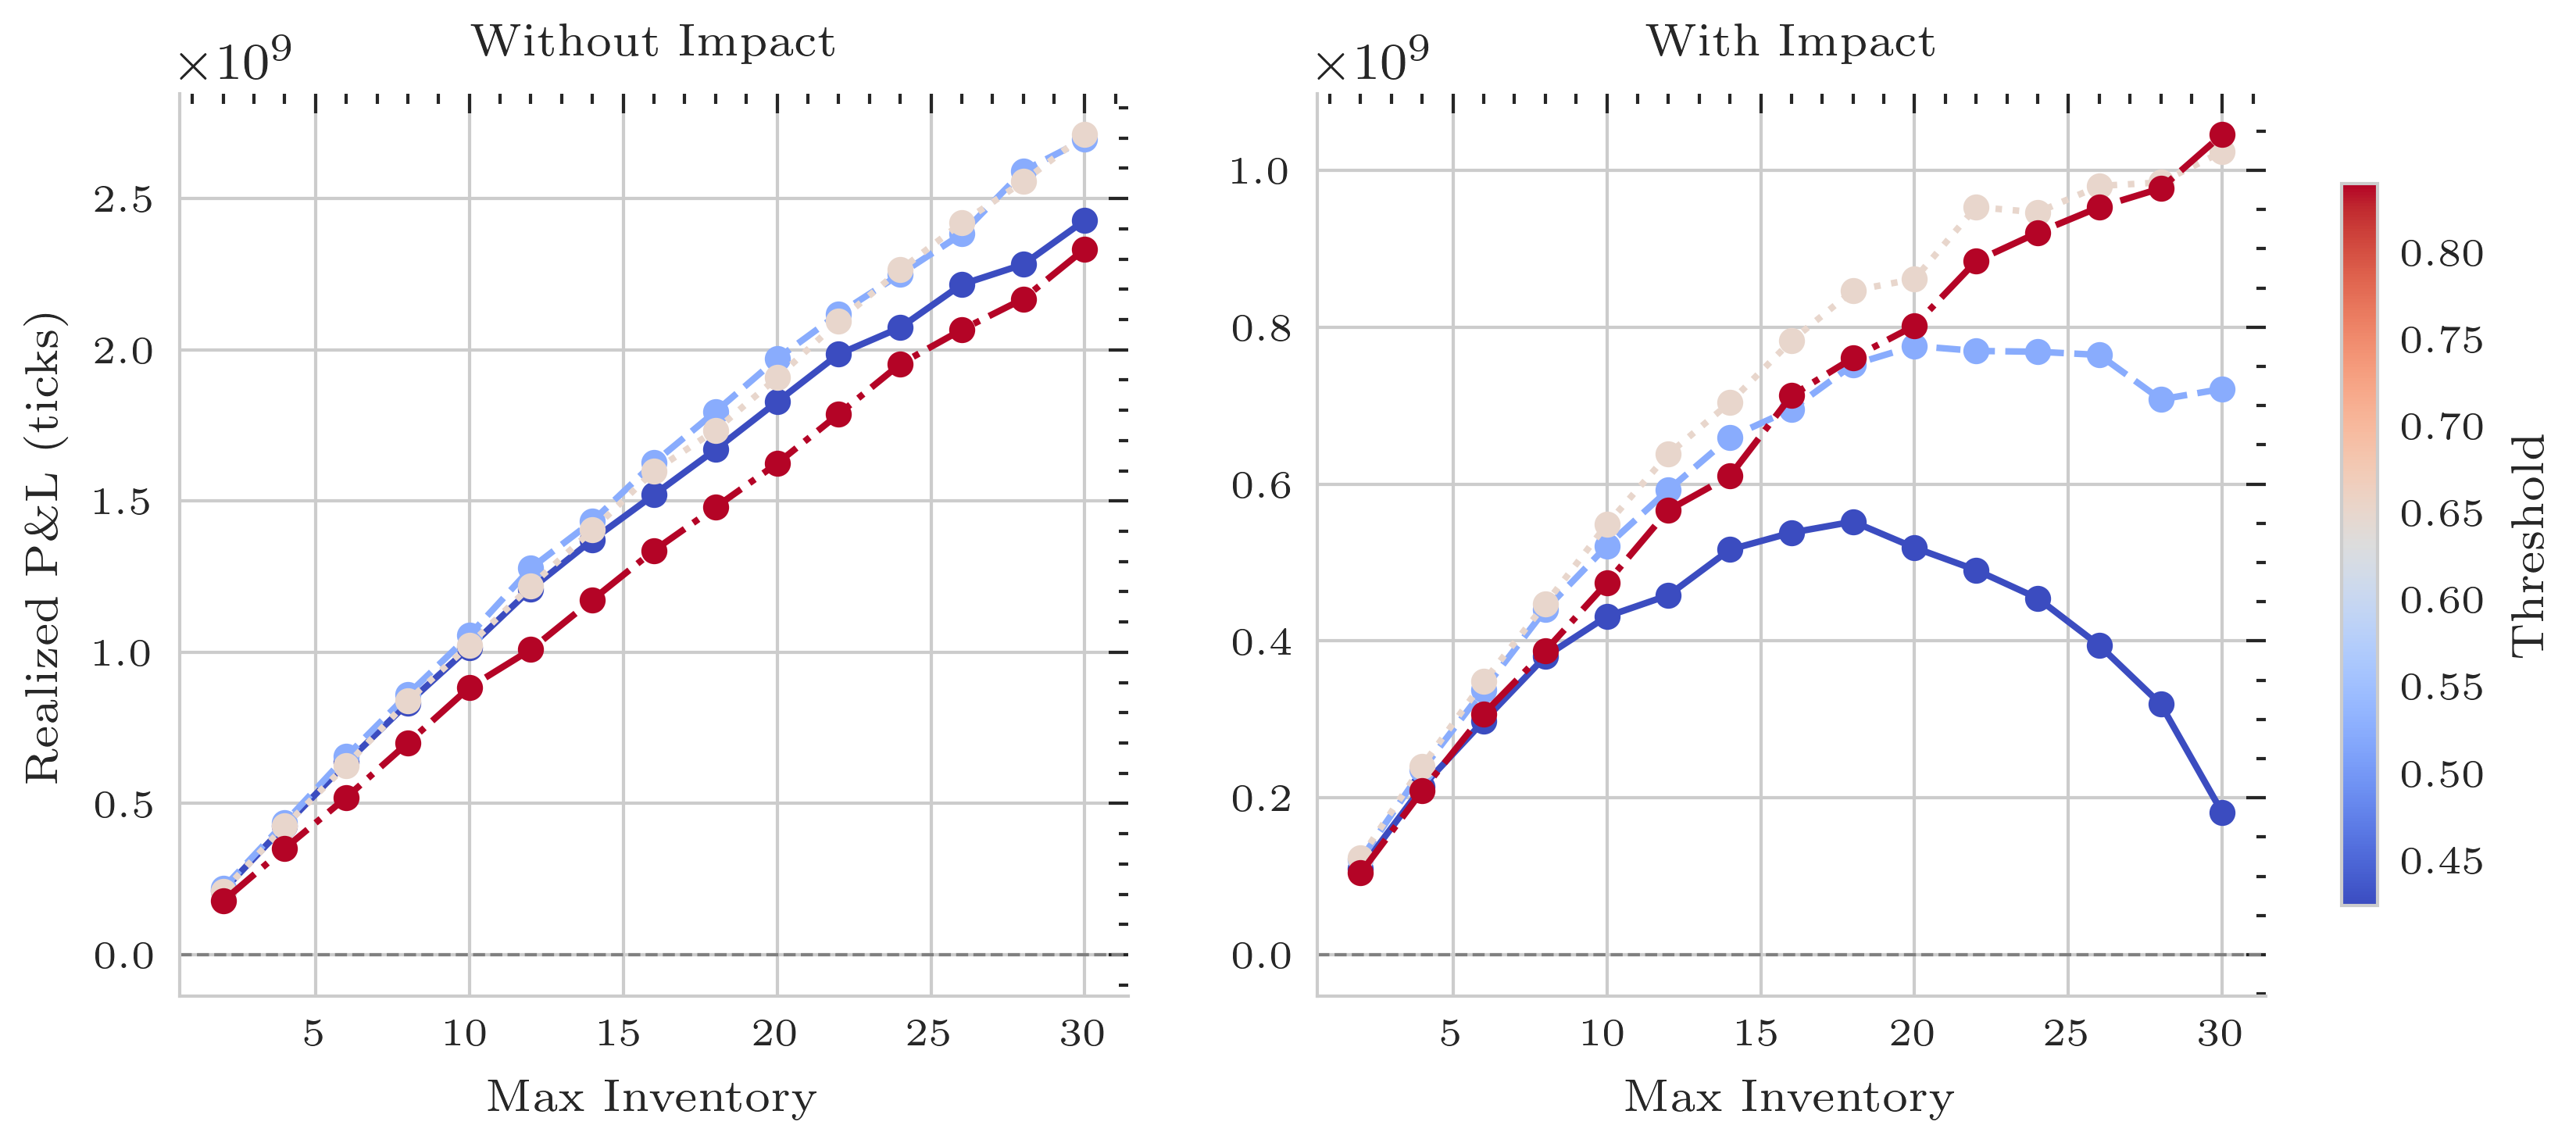

In [5]:
def plot_pnl_comparison(df_no_impact, df_impact, q_max):
    with plt.style.context(["science", "ieee"]), mpl.rc_context(
        {"axes.facecolor": "white", "font.serif": ["Times New Roman", "DejaVu Serif"]}
    ):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 2.5), sharey=False)
        fig.patch.set_alpha(0)

        thresholds = sorted(
            df_no_impact.filter(pl.col("q_max") == q_max)["threshold"]
            .unique()
            .to_list()
        )
        norm = mcolors.Normalize(vmin=min(thresholds), vmax=max(thresholds))
        cmap = cm.coolwarm

        for ax, df, title in [
            (ax1, df_no_impact, r"Without Impact"),
            (ax2, df_impact, r"With Impact"),
        ]:
            sub = df.filter(pl.col("q_max") == q_max)
            for thr in thresholds:
                s = sub.filter(pl.col("threshold") == thr).sort("max_inventory")
                ax.plot(
                    s["max_inventory"],
                    s["realized_pnl"],
                    color=cmap(norm(thr)),
                    lw=1,
                    marker="o",
                    markersize=3,
                )
            ax.axhline(0, color="grey", lw=0.5, ls="--")
            ax.set_title(title, fontsize=7)
            ax.set_xlabel("Max Inventory", fontsize=7)
            ax.tick_params(labelsize=6)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        ax1.set_ylabel(r"Realized P\&L (ticks)", fontsize=7)

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        cbar = fig.colorbar(sm, ax=[ax1, ax2], shrink=0.8, pad=0.03)
        cbar.set_label("Threshold", fontsize=7)
        cbar.ax.tick_params(labelsize=6)

        # fig.tight_layout(pad=0.3)
        # fig.savefig("../../paper/pnl_vs_max_inventory_PFE.pdf", bbox_inches="tight")
        plt.show()


plot_pnl_comparison(pnl_no_impact, pnl_impact, q_max=5)

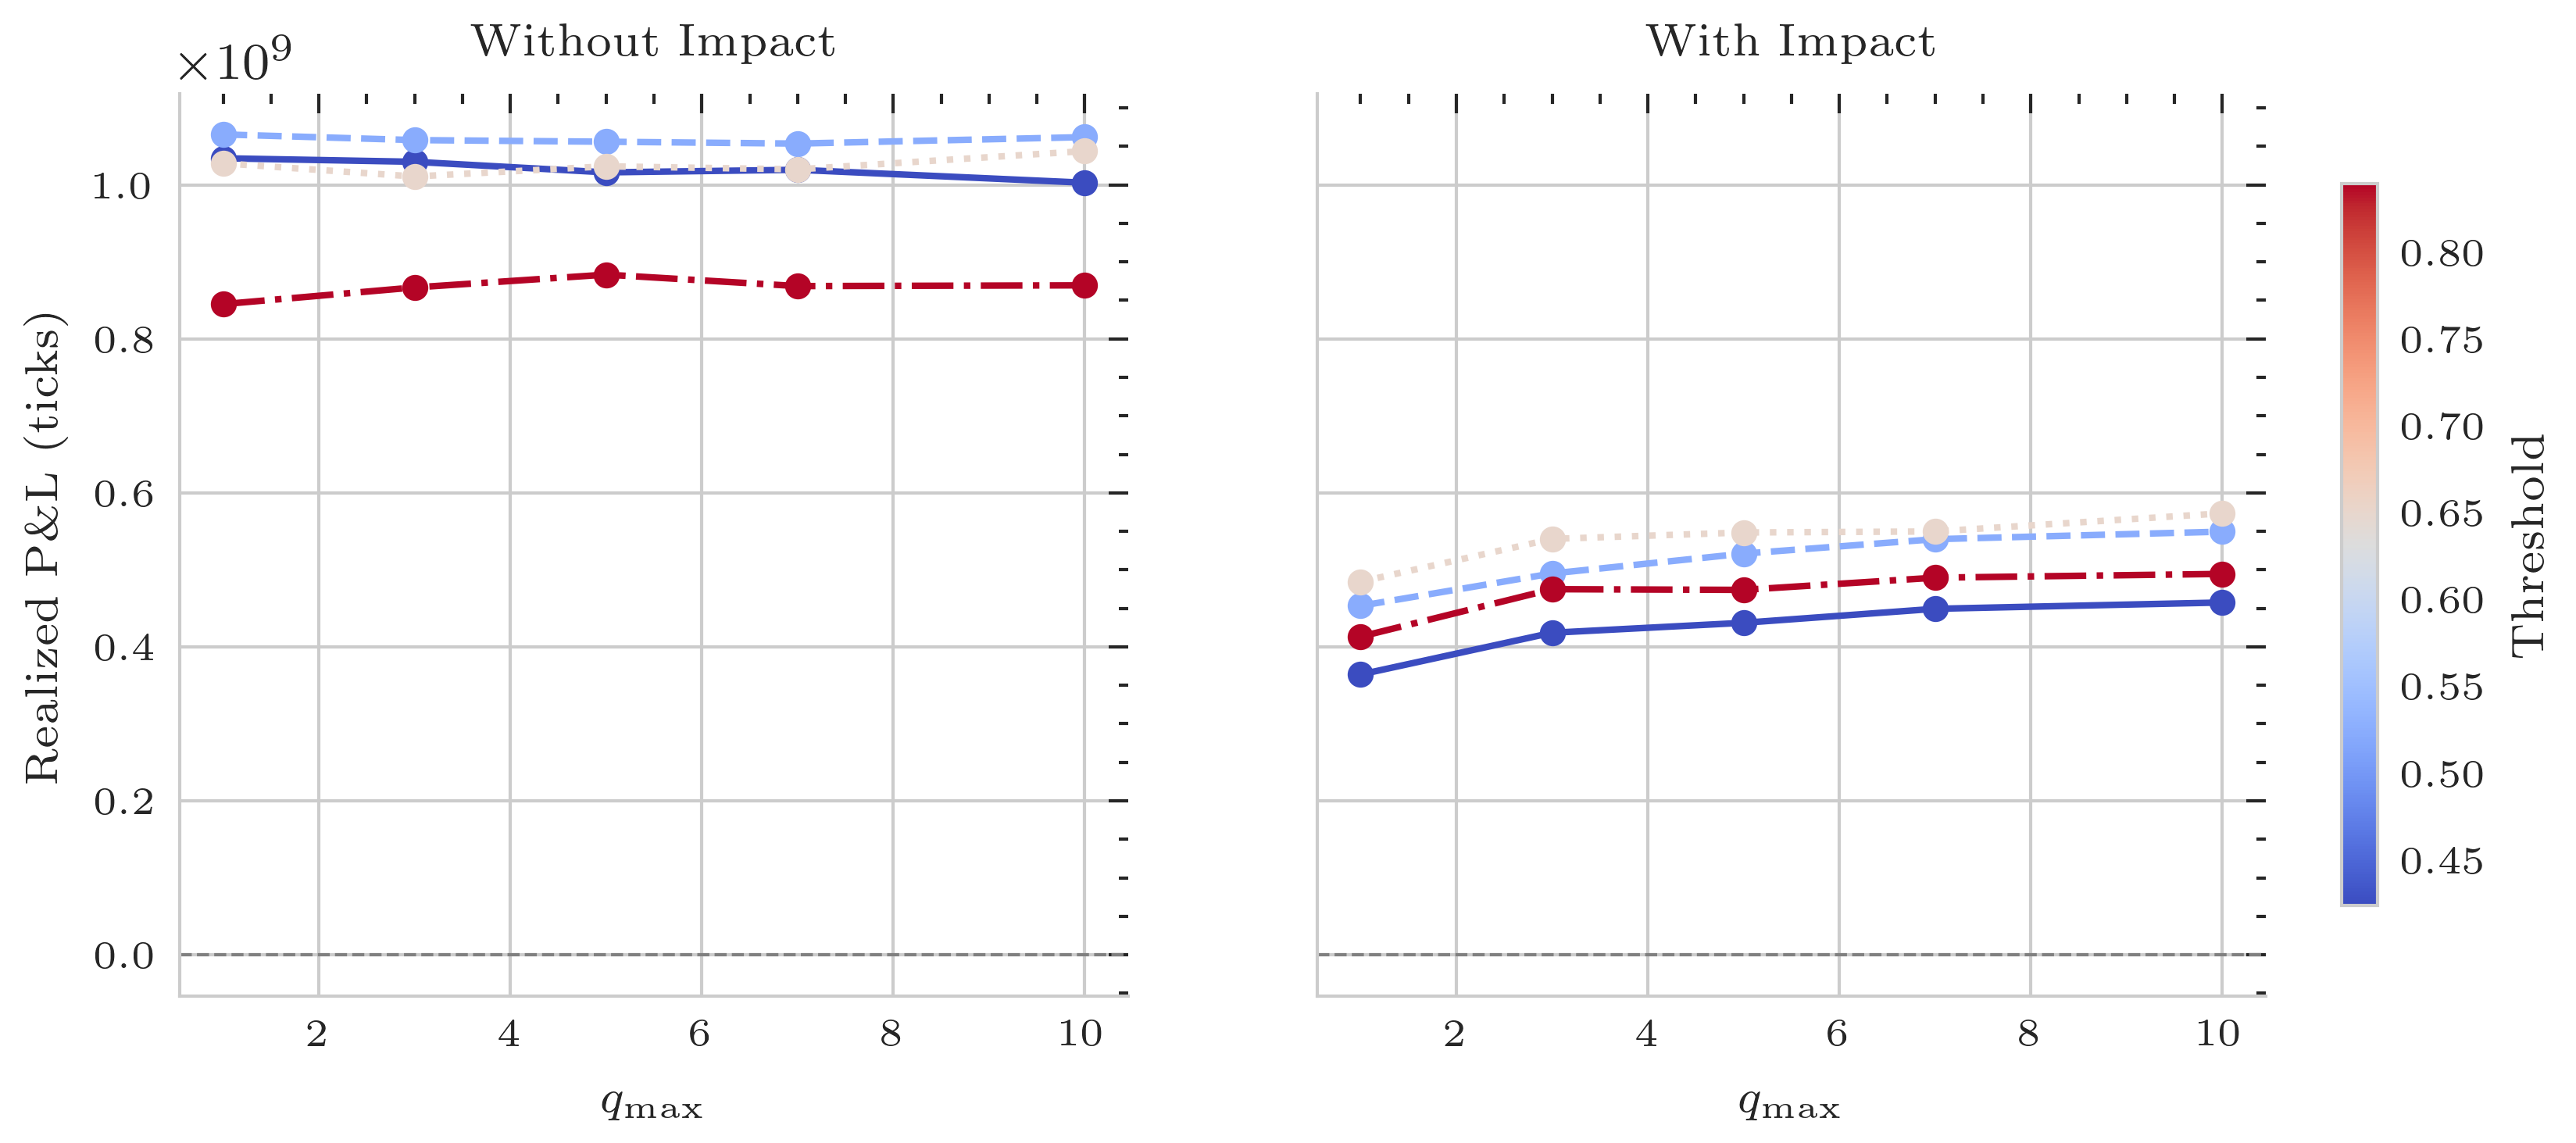

In [6]:
def plot_pnl_vs_qmax(df_no_impact, df_impact, max_inventory):
    with plt.style.context(["science", "ieee"]), mpl.rc_context(
        {"axes.facecolor": "white", "font.serif": ["Times New Roman", "DejaVu Serif"]}
    ):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 2.5), sharey=True)
        fig.patch.set_alpha(0)

        thresholds = sorted(
            df_no_impact.filter(pl.col("max_inventory") == max_inventory)["threshold"]
            .unique()
            .to_list()
        )
        norm = mcolors.Normalize(vmin=min(thresholds), vmax=max(thresholds))
        cmap = cm.coolwarm

        for ax, df, title in [
            (ax1, df_no_impact, "Without Impact"),
            (ax2, df_impact, "With Impact"),
        ]:
            sub = df.filter(pl.col("max_inventory") == max_inventory)
            for thr in thresholds:
                s = sub.filter(pl.col("threshold") == thr).sort("q_max")
                ax.plot(
                    s["q_max"],
                    s["realized_pnl"],
                    color=cmap(norm(thr)),
                    lw=1,
                    marker="o",
                    markersize=3,
                )
            ax.axhline(0, color="grey", lw=0.5, ls="--")
            ax.set_title(title, fontsize=7)
            ax.set_xlabel(r"$q_{\max}$", fontsize=7)
            ax.tick_params(labelsize=6)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        ax1.set_ylabel(r"Realized P\&L (ticks)", fontsize=7)

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        cbar = fig.colorbar(sm, ax=[ax1, ax2], shrink=0.8, pad=0.03)
        cbar.set_label("Threshold", fontsize=7)
        cbar.ax.tick_params(labelsize=6)

        # fig.savefig("../../paper/pnl_vs_qmax_PFE.pdf", bbox_inches="tight")
        plt.show()


plot_pnl_vs_qmax(pnl_no_impact, pnl_impact, max_inventory=10)